# 04: PC Algorithm for Continuous Data

This lesson runs the PC algorithm on the continuous synthetic data created earlier in the tutorial series. PC is a constraint-based causal discovery algorithm: it starts with a dense undirected graph, removes edges when conditional independence tests find separating sets, and then applies orientation rules to identify arrows that are supported by the discovered independence structure.

The most important lesson is that PC does not simply draw arrows from correlations. It uses many local conditional independence decisions. That means the final graph depends on:

- the conditional independence test family;
- the alpha threshold used for independence decisions;
- sample size;
- whether the algorithm's assumptions are close enough to the data-generating process;
- whether the graph is identifiable from observational data.

Here we use `linear_gaussian`, the friendliest dataset from lesson 02, because it matches Fisher-Z assumptions. Then we deliberately vary alpha, sample size, stable versus original PC behavior, and nonlinear data to see where the graph becomes less reliable.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **PC Algorithm For Continuous Data**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment tests constraint-based graph discovery under assumptions that can be checked only because the synthetic truth is known.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

The PC family starts from a complete undirected graph and removes edges when it finds a separating set,

$$
\text{remove } X_i-X_j \quad \text{if there exists } S \text{ such that } X_i \perp\!\!\!\perp X_j \mid S.
$$

After skeleton discovery, orientation rules use v-structures such as

$$
X_i \rightarrow X_k \leftarrow X_j, \qquad X_i \not\sim X_j.
$$

Prior knowledge, missing data handling, and discrete tests affect the reliability of these two steps. They do not change the object being estimated.



We will keep the workflow close to how a real causal discovery analysis should be presented:

1. Set up imports, paths, and causal-learn PC utilities.
2. Load the continuous synthetic dataset and its known true DAG.
3. Review the PC assumptions and algorithm stages.
4. Run baseline stable PC with Fisher-Z.
5. Convert the learned graph into readable edge tables and figures.
6. Evaluate skeleton recovery and arrow recovery against the true graph.
7. Inspect separating sets and the raw graph matrix.
8. Study alpha sensitivity, sample size sensitivity, and stable PC behavior.
9. Stress-test Fisher-Z PC on nonlinear continuous data.
10. Close with reporting guidance.

The lesson is detailed because PC is one of the core algorithms that many later causal discovery methods build on or compare against.





## Tutorial Workflow

### PC Algorithm Theory

The PC algorithm is a constraint-based causal discovery method. PC asks a sequence of conditional independence questions and uses the answers to remove edges and orient the remaining structure.

The core idea is: if two variables are independent after conditioning on some set of other variables, then they probably do not need a direct edge between them in the causal graph. PC starts with a complete undirected graph, removes edges when it finds separating sets, and then applies orientation rules to convert as many remaining edges as possible into directed edges.

PC is best understood as a graph-recovery procedure under assumptions. The conditional independence tests, the significance level, the sample size, and the assumptions about hidden variables all shape the final graph.


### Markov, Faithfulness, and Causal Sufficiency

PC relies on three major assumptions.

The **causal Markov condition** says that each variable is independent of its non-effects after conditioning on its direct causes. In a DAG, this is what lets graphical separation imply statistical independence.

**Faithfulness** says the reverse is also reliable: the independencies we see in data are exactly the independencies implied by the graph. If two causal paths cancel each other numerically, the data might show independence even though a causal path exists. That kind of cancellation breaks faithfulness and can mislead PC.

**Causal sufficiency** says there are no unobserved common causes among the measured variables. Standard PC assumes that if two observed variables are associated, the explanation is inside the observed variable set. If a hidden confounder drives both variables, PC may draw an ordinary edge where a latent-confounding representation would be more honest.


### Skeleton Discovery and Separating Sets

PC begins with every variable connected to every other variable. Then it searches for conditioning sets that make pairs independent.

For example, if `need` and `engagement` are associated marginally, PC may initially keep an edge. But if `need` becomes independent of `engagement` after conditioning on `match`, then `match` is a separating variable and the direct `need -- engagement` edge can be removed.

The set that makes two variables independent is called a **separating set** or **sepset**. PC stores these sepsets because they are needed later for collider orientation. Skeleton discovery is therefore more than edge deletion; it also builds the evidence used by the orientation phase.

The search becomes harder as conditioning sets get larger. With limited data, high-order conditional independence tests are noisy, so PC can make early mistakes that propagate into later orientations.


#### Collider Orientation and Meek Rules

After skeleton discovery, PC looks for unshielded triples: patterns like `X - Z - Y` where `X` and `Y` are not adjacent. If `Z` was **not** in the separating set for `X` and `Y`, PC orients the triple as a collider:

$$
X \rightarrow Z \leftarrow Y
$$

This matters because colliders create a distinctive independence pattern. The parents of a collider can be marginally independent but become dependent after conditioning on the collider or its descendants.

After colliders are oriented, PC applies propagation rules often called **Meek rules**. These rules orient additional edges when doing so is logically forced by already oriented structures and the requirement that the graph remain acyclic. The algorithm orients only what is compelled; it should not invent directions where the data and rules do not support them.


#### CPDAGs and Markov Equivalence

PC usually returns a partially directed graph that preserves orientation uncertainty. This is expected. Many DAGs can imply the same set of conditional independencies; such DAGs belong to the same **Markov equivalence class**.

A CPDAG represents that equivalence class. Directed edges are compelled: every DAG in the equivalence class agrees on that direction. Undirected edges are reversible: the available conditional independence information does not determine their direction.

This is why a PC result should not be judged only by whether every arrow matches a hidden truth graph. If an edge is genuinely not identifiable from observational conditional independencies, leaving it unoriented is more honest than forcing a direction.


#### Fisher-Z Tests for Continuous Data

In this lesson, PC uses the Fisher-Z conditional independence test. Fisher-Z is natural for continuous linear Gaussian settings because it tests whether the partial correlation between two variables is zero after conditioning on a set.

The significance level `alpha` controls the edge-removal threshold. A larger `alpha` makes it easier to reject independence, which tends to keep more edges. A smaller `alpha` makes independence easier to accept, which tends to remove more edges.

This means `alpha` is not a cosmetic setting. It changes the graph. A responsible PC workflow reports the independence test, the alpha value, sample size, and sensitivity to alpha.


### What PC Can and Cannot Claim

PC can recover a CPDAG under strong assumptions and reliable conditional independence tests. It can identify some compelled directions, especially colliders, and it can reveal which adjacencies are supported by conditional dependence patterns.

PC cannot guarantee a fully directed causal graph from observational data alone. It is also vulnerable to hidden confounders, selection bias, measurement error, faithfulness violations, and weak sample sizes. In continuous data, nonlinear relationships can also make a linear Fisher-Z test miss important dependencies.

The practical lesson is to read PC output as a structured causal hypothesis. The graph is strongest when assumptions are plausible, directions are stable across settings, and the result agrees with domain constraints or complementary methods.


#### Setup

The setup block imports the scientific stack, the PC algorithm, and causal-learn's graph metrics. It also prepares output folders and records package versions. The `MPLCONFIGDIR` setting keeps matplotlib cache files inside the repository workspace during execution.


In [1]:
# Define reusable helpers for the Setup section.
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import os
import warnings
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from causallearn.search.ConstraintBased.PC import pc
from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.Dag import Dag
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.graph.Edge import Edge
from causallearn.graph.Endpoint import Endpoint
from causallearn.graph.SHD import SHD
from causallearn.graph.AdjacencyConfusion import AdjacencyConfusion
from causallearn.graph.ArrowConfusion import ArrowConfusion
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", 140)
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "causal_learn":
    NOTEBOOK_DIR = Path("notebooks/tutorials/causal_learn").resolve()
else:
    NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATASET_DIR = OUTPUT_DIR / "datasets"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, DATASET_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
NOTEBOOK_PREFIX = "04"
RANDOM_SEED = 42
BASE_ALPHA = 0.05
def pkg_version(package_name: str) -> str:
    """
    Return a package version string without failing if metadata is unavailable.
    
    Parameters
    ----------
    package_name : str
        Package name to look up in Python package metadata.
    
    Returns
    -------
    str
        Installed package version, or `not installed` when the package cannot be found.
    """
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"
version_table = pd.DataFrame(
    [
        {"package": "causal-learn", "version": pkg_version("causal-learn")},
        {"package": "numpy", "version": pkg_version("numpy")},
        {"package": "pandas", "version": pkg_version("pandas")},
        {"package": "matplotlib", "version": pkg_version("matplotlib")},
        {"package": "seaborn", "version": pkg_version("seaborn")},
    ]
)
version_table


,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table is the reproducibility anchor for the lesson. Graph outputs can change when packages, random seeds, or tuning choices change, so the environment should be visible next to the results.


#### Load Continuous Data and Ground Truth

We use `02_linear_gaussian.csv` from the synthetic data factory. That dataset was designed to be friendly to Fisher-Z PC: continuous variables, linear additive structural equations, Gaussian noise, and no hidden common causes in the observed graph.

We also load the true edge table so the learned graph can be evaluated honestly.


In [2]:
linear_path = DATASET_DIR / "02_linear_gaussian.csv"
nonlinear_path = DATASET_DIR / "02_nonlinear_continuous.csv"
true_edge_path = TABLE_DIR / "02_base_true_dag_edges.csv"
missing_inputs = [str(path) for path in [linear_path, nonlinear_path, true_edge_path] if not path.exists()]
if missing_inputs:
    raise FileNotFoundError("Run notebook 02 before this lesson. Missing: " + ", ".join(missing_inputs))
linear_data = pd.read_csv(linear_path)
nonlinear_data = pd.read_csv(nonlinear_path)
true_edge_table_raw = pd.read_csv(true_edge_path)
node_order = ["need", "intent", "match", "engagement", "renewal", "support"]
true_edge_table = true_edge_table_raw[["source", "target", "edge_type", "mechanism"]].copy()
true_edge_table["mark"] = "-->"
load_summary = pd.DataFrame(
    [
        {
            "dataset_name": "linear_gaussian",
            "rows": linear_data.shape[0],
            "columns": linear_data.shape[1],
            "column_list": ", ".join(linear_data.columns),
        },
        {
            "dataset_name": "nonlinear_continuous",
            "rows": nonlinear_data.shape[0],
            "columns": nonlinear_data.shape[1],
            "column_list": ", ".join(nonlinear_data.columns),
        },
    ]
)
load_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_data_summary.csv", index=False)
load_summary


,dataset_name,rows,columns,column_list
0,linear_gaussian,2500,6,"need, intent, match, engagement, renewal, support"
1,nonlinear_continuous,2500,6,"need, intent, match, engagement, renewal, support"


Both datasets have the same observed columns. The baseline PC run will use the linear Gaussian data; the nonlinear dataset appears later as a stress test for what happens when Fisher-Z assumptions are less appropriate.


#### True DAG Edge Table

The true edge table is the answer key. PC should try to recover the adjacency pattern and, where identifiable, the orientations implied by the conditional independence structure.


In [3]:
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_edges_used.csv", index=False)
true_edge_table


,source,target,edge_type,mechanism,mark
0,need,match,directed,Need changes what a good match means.,-->
1,intent,match,directed,Current intent changes recommendation relevance.,-->
2,match,engagement,directed,Better matching increases engagement depth.,-->
3,intent,renewal,directed,Intent directly affects later value.,-->
4,engagement,renewal,directed,Engagement contributes to renewal value.,-->
5,engagement,support,directed,Engagement creates more chances for support contact.,-->


This edge table is small. With only six variables, we can inspect every learned edge by hand and understand exactly what each graph metric is counting.


### PC Assumptions and Stages

PC is powerful, but its output is only as credible as its assumptions. This table summarizes the conceptual contract for the baseline run.


| assumption_or_stage | plain_language | why_it_matters |
| --- | --- | --- |
| Causal Markov condition | The graph implies the conditional independences in the data. | PC removes edges using conditional independence tests. |
| Faithfulness | Independences in the data are explained by the graph, not by exact coefficient cancellations. | If faithfulness fails, PC can remove or keep the wrong edges. |
| Causal sufficiency | All common causes of observed variables are included. | PC targets a DAG/CPDAG under observed sufficiency; FCI is safer with hidden common causes. |
| Correct CI test | Fisher-Z is appropriate for approximately linear Gaussian continuous data. | A mismatched test can create false edge deletions or false retained edges. |
| Skeleton search | Start dense, then remove edges when separating sets are found. | This controls which variable pairs remain adjacent. |
| Orientation rules | Orient colliders and propagate directions without introducing cycles or contradictions. | Some directions are identifiable, while others may remain undirected. |


This checklist is the right frame for reading every PC graph below. A clean graph recovery result on synthetic linear Gaussian data does not mean the same settings will work on nonlinear, discrete, missing, or hidden-confounder data.





## Diagnostics and Interpretation

### Data Audit Before Running PC

Before running discovery, we check basic shape, missingness, and summary statistics. This dataset is synthetic, but the audit habit matters: PC can be sensitive to missingness, nonnumeric columns, duplicated columns, and extreme scaling problems.


In [4]:
data_audit = pd.DataFrame(
    [
        {
            "variable": column,
            "dtype": str(linear_data[column].dtype),
            "missing_rate": linear_data[column].isna().mean(),
            "mean": linear_data[column].mean(),
            "std": linear_data[column].std(ddof=0),
            "min": linear_data[column].min(),
            "median": linear_data[column].median(),
            "max": linear_data[column].max(),
        }
        for column in node_order
    ]
)
data_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_data_audit.csv", index=False)
data_audit


,variable,dtype,missing_rate,mean,std,min,median,max
0,need,float64,0.0,3.552714e-18,1.0,-3.371900,0.019662,3.316358
1,intent,float64,0.0,-9.947598e-18,1.0,-3.467962,-0.012950,3.389982
2,match,float64,0.0,-3.552714e-19,1.0,-3.596272,0.001127,3.917631
3,engagement,float64,0.0,-1.776357e-18,1.0,-3.404627,0.004449,3.469112
4,renewal,float64,0.0,-8.526513e-18,1.0,-3.418065,-0.024579,3.122549
5,support,float64,0.0,1.563194e-17,1.0,-3.250120,-0.007028,3.174916


The variables are numeric, complete, centered, and scaled. That makes the baseline PC result easier to attribute to graph structure because data preparation is kept simple.


### Correlation Map Before Conditional Testing

A correlation heatmap serves a different role than a causal graph. It is a useful first diagnostic. It shows which variables are associated before PC starts conditioning on other variables to remove indirect relationships.


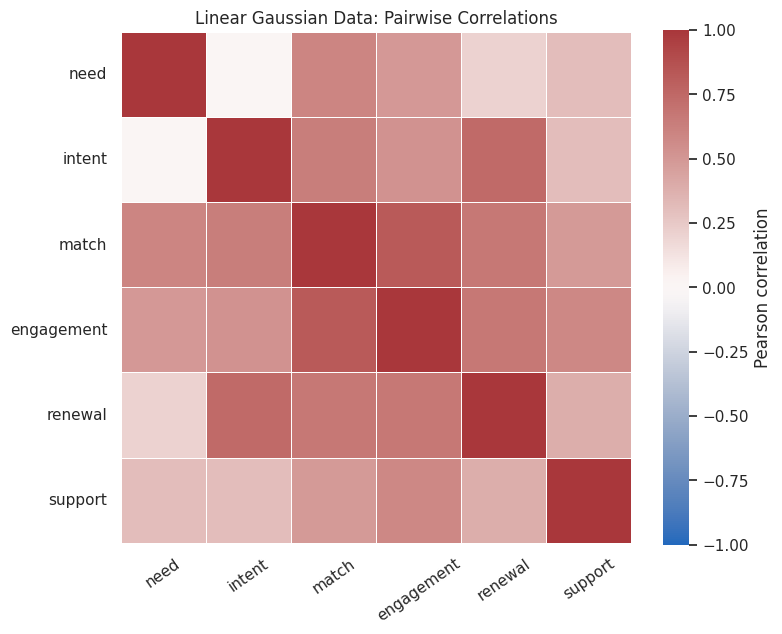

In [5]:
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    linear_data[node_order].corr(),
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Linear Gaussian Data: Pairwise Correlations")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
correlation_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_correlation_heatmap.png"
fig.savefig(correlation_path, dpi=160, bbox_inches="tight")
plt.show()


Many non-adjacent variables are correlated because causal paths transmit association. PC's job is to decide which of these pairwise associations disappear after conditioning on appropriate separating sets.




#### Graph Conversion and Drawing Helpers

The PC output is a causal-learn graph object. The helper functions below convert that object into readable edge tables, compute graph metrics, and draw graphs in the same visual style used across the tutorial.


In [6]:
# Define reusable helpers for the Graph Conversion And Drawing Helpers section.
endpoint_to_mark = {
    ("TAIL", "ARROW"): "-->",
    ("ARROW", "TAIL"): "<--",
    ("TAIL", "TAIL"): "---",
    ("ARROW", "ARROW"): "<->",
    ("CIRCLE", "ARROW"): "o->",
    ("ARROW", "CIRCLE"): "<-o",
    ("CIRCLE", "CIRCLE"): "o-o",
}
def graph_to_edge_table(graph):
    """
    Convert a causal-learn graph object into a readable edge table.
    
    Parameters
    ----------
    graph : object
        Graph object returned by causal-learn or constructed from the edge table.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = []
    for edge in graph.get_graph_edges():
        node1 = edge.get_node1().get_name()
        node2 = edge.get_node2().get_name()
        endpoint1 = str(edge.get_endpoint1())
        endpoint2 = str(edge.get_endpoint2())
        mark = endpoint_to_mark.get((endpoint1, endpoint2), f"{endpoint1}/{endpoint2}")
        if mark == "<--":
            source, target, display_mark = node2, node1, "-->"
            edge_kind = "directed"
        elif mark == "-->":
            source, target, display_mark = node1, node2, "-->"
            edge_kind = "directed"
        elif mark == "---":
            source, target, display_mark = node1, node2, "---"
            edge_kind = "undirected"
        elif mark == "<->":
            source, target, display_mark = node1, node2, "<->"
            edge_kind = "bidirected"
        else:
            source, target, display_mark = node1, node2, mark
            edge_kind = "partially_oriented"
        rows.append(
            {
                "source": source,
                "target": target,
                "mark": display_mark,
                "edge_kind": edge_kind,
                "causal_learn_edge": str(edge),
                "endpoint_at_node1": endpoint1,
                "endpoint_at_node2": endpoint2,
            }
        )
    return pd.DataFrame(rows).sort_values(["source", "target", "mark"]).reset_index(drop=True)
def directed_edges(edge_table):
    """
    Return directed arrow claims as ordered pairs.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    
    Returns
    -------
    set[tuple[str, str]]
        Directed source-target edge set extracted from the edge table.
    """
    return {
        (row.source, row.target)
        for row in edge_table.itertuples(index=False)
        if row.mark == "-->"
    }
def skeleton_edges(edge_table):
    """
    Return adjacencies as unordered pairs.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    
    Returns
    -------
    set[frozenset[str]]
        Undirected skeleton edge set extracted from the edge table.
    """
    return {frozenset([row.source, row.target]) for row in edge_table.itertuples(index=False)}
def safe_ratio(numerator, denominator):
    """
    Idea: Compute a ratio while returning a missing value when the denominator is too small to support the comparison.
    
    Parameters
    ----------
    numerator : float
        Numerator of the ratio being computed.
    denominator : float
        Denominator of the ratio being computed.
    
    Returns
    -------
    float
        Ratio value, or NaN when the denominator cannot support a stable ratio.
    """
    return np.nan if denominator == 0 else numerator / denominator
def evaluate_learned_graph(candidate_name, truth_table, learned_table):
    """
    Compute skeleton and arrow metrics for one learned edge table.
    
    Parameters
    ----------
    candidate_name : str
        Readable name for the candidate graph being evaluated.
    truth_table : pd.DataFrame
        Oracle edge table used as the graph-recovery benchmark.
    learned_table : pd.DataFrame
        Learned edge table returned by a discovery algorithm.
    
    Returns
    -------
    dict[str, object]
        Graph-recovery metrics for one learned graph, including skeleton, arrow, reversal, and missing-edge counts.
    """
    truth_skeleton = skeleton_edges(truth_table)
    learned_skeleton = skeleton_edges(learned_table)
    truth_directed = directed_edges(truth_table)
    learned_directed = directed_edges(learned_table)
    skeleton_tp = len(truth_skeleton & learned_skeleton)
    skeleton_fp = len(learned_skeleton - truth_skeleton)
    skeleton_fn = len(truth_skeleton - learned_skeleton)
    arrow_tp = len(truth_directed & learned_directed)
    arrow_fp = len(learned_directed - truth_directed)
    arrow_fn = len(truth_directed - learned_directed)
    reversed_arrows = sum((target, source) in learned_directed for source, target in truth_directed)
    unresolved_true_edges = sum(
        frozenset([row.source, row.target]) in learned_skeleton
        and (row.source, row.target) not in learned_directed
        and (row.target, row.source) not in learned_directed
        for row in truth_table.itertuples(index=False)
    )
    return {
        "candidate": candidate_name,
        "learned_edges": len(learned_table),
        "skeleton_tp": skeleton_tp,
        "skeleton_fp": skeleton_fp,
        "skeleton_fn": skeleton_fn,
        "skeleton_precision": safe_ratio(skeleton_tp, skeleton_tp + skeleton_fp),
        "skeleton_recall": safe_ratio(skeleton_tp, skeleton_tp + skeleton_fn),
        "arrow_tp": arrow_tp,
        "arrow_fp": arrow_fp,
        "arrow_fn": arrow_fn,
        "arrow_precision": safe_ratio(arrow_tp, arrow_tp + arrow_fp),
        "arrow_recall": safe_ratio(arrow_tp, arrow_tp + arrow_fn),
        "reversed_arrows": reversed_arrows,
        "unresolved_true_edges": unresolved_true_edges,
    }
"graph helpers ready"


'graph helpers ready'

The evaluation separates skeleton recovery from arrow recovery. This distinction matters because PC may correctly keep two variables adjacent while leaving the direction unresolved or orienting it incorrectly under finite-sample noise.


#### Drawing Helper for DAG-Style Graphs

This renderer uses the shared tutorial visual style: wide canvas, rounded pastel boxes, bold labels, dark arrows, and enough spacing that arrowheads are visible. Undirected CPDAG-style edges are drawn as solid lines without arrowheads.


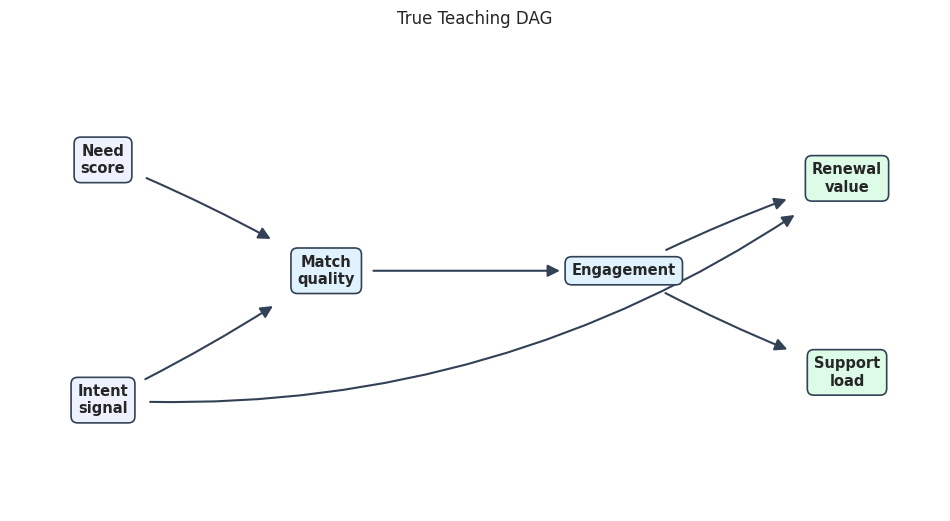

PosixPath('notebooks/tutorials/causal_learn/outputs/figures/04_true_dag.png')

In [7]:
# Define reusable helpers for the Drawing Helper For DAG-Style Graphs section.
node_labels = {
    "need": "Need\nscore",
    "intent": "Intent\nsignal",
    "match": "Match\nquality",
    "engagement": "Engagement",
    "renewal": "Renewal\nvalue",
    "support": "Support\nload",
}
node_positions = {
    "need": (0.10, 0.76),
    "intent": (0.10, 0.24),
    "match": (0.34, 0.52),
    "engagement": (0.66, 0.52),
    "renewal": (0.90, 0.72),
    "support": (0.90, 0.30),
}
node_colors = {
    "need": "#eef2ff",
    "intent": "#eef2ff",
    "match": "#e0f2fe",
    "engagement": "#e0f2fe",
    "renewal": "#dcfce7",
    "support": "#dcfce7",
}
edge_radii = {
    ("need", "match"): -0.04,
    ("intent", "match"): 0.04,
    ("match", "engagement"): 0.00,
    ("intent", "renewal"): 0.18,
    ("engagement", "renewal"): -0.04,
    ("engagement", "support"): 0.04,
    ("need", "renewal"): -0.20,
    ("need", "support"): -0.08,
    ("intent", "support"): 0.18,
    ("match", "renewal"): -0.08,
    ("support", "need"): 0.12,
    ("renewal", "need"): -0.18,
}
def draw_edge_table_graph(edge_table, title, path, positions=node_positions, labels=node_labels, colors=node_colors):
    """
    Draw a learned or true graph in the shared tutorial style.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    title : str
        Title shown above the plot.
    path : str or pathlib.Path
        Optional output path for the figure.
    positions : dict
        Node positions used to draw the graph.
    labels : dict[str, str]
        Display labels used for graph nodes in the rendered figure.
    colors : dict[str, str]
        Mapping from node names or groups to display colors.
    
    Returns
    -------
    pathlib.Path
        Path to the saved graph figure drawn from the edge table.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()
    for row in edge_table.itertuples(index=False):
        source = row.source
        target = row.target
        mark = row.mark
        rad = edge_radii.get((source, target), edge_radii.get((target, source), 0.0))
        arrowstyle = "-|>" if mark == "-->" else "-"
        linestyle = "--" if mark in {"o->", "<-o", "o-o"} else "-"
        ax.annotate(
            "",
            xy=positions[target],
            xytext=positions[source],
            arrowprops=dict(
                arrowstyle=arrowstyle,
                color="#334155",
                linewidth=1.5,
                mutation_scale=18,
                shrinkA=34,
                shrinkB=46,
                linestyle=linestyle,
                connectionstyle=f"arc3,rad={rad}",
            ),
            zorder=1,
        )
    for node, (x, y) in positions.items():
        ax.text(
            x,
            y,
            labels[node],
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor=colors.get(node, "#e0f2fe"),
                edgecolor="#334155",
                linewidth=1.2,
            ),
            zorder=2,
        )
    ax.set_title(title, pad=18)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path
true_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_dag.png"
draw_edge_table_graph(true_edge_table, "True Teaching DAG", true_graph_path)


The true graph figure is the visual baseline for the rest of the lesson. Each learned PC graph can be compared against this layout without mentally rearranging variables.


#### Run Baseline Stable PC

The baseline run uses settings that match the synthetic data:

- `indep_test="fisherz"` for continuous linear Gaussian-style data;
- `alpha=0.05` as the conditional-independence threshold;
- `stable=True` so skeleton discovery is less sensitive to variable order.

The result is a causal-learn `CausalGraph` object containing a learned graph and separating-set information.


In [8]:
baseline_pc = pc(
    linear_data[node_order].to_numpy(),
    alpha=BASE_ALPHA,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=node_order,
)
baseline_edge_table = graph_to_edge_table(baseline_pc.G)
baseline_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_pc_edges.csv", index=False)
baseline_edge_table


,source,target,mark,edge_kind,causal_learn_edge,endpoint_at_node1,endpoint_at_node2
0,engagement,renewal,-->,directed,engagement --> renewal,TAIL,ARROW
1,engagement,support,-->,directed,engagement --> support,TAIL,ARROW
2,intent,match,-->,directed,intent --> match,TAIL,ARROW
3,intent,renewal,-->,directed,intent --> renewal,TAIL,ARROW
4,match,engagement,-->,directed,match --> engagement,TAIL,ARROW
5,need,match,-->,directed,need --> match,TAIL,ARROW


The baseline learned edge table is already very close to the true edge table. Because this dataset was designed for Fisher-Z PC, this is the friendly case where the algorithm's assumptions and the data-generating process are aligned.


### Baseline Learned Graph

The next figure draws the learned graph using the same positions as the true DAG. Matching positions make extra, missing, reversed, or unresolved edges easier to see.


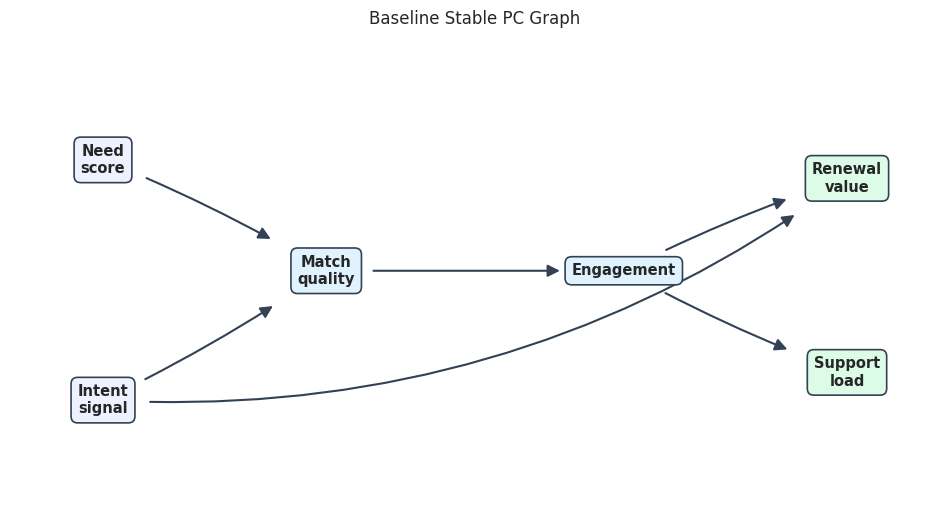

PosixPath('notebooks/tutorials/causal_learn/outputs/figures/04_baseline_pc_graph.png')

In [9]:
baseline_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_pc_graph.png"
draw_edge_table_graph(baseline_edge_table, "Baseline Stable PC Graph", baseline_graph_path)


The learned graph matches the intended structure in this synthetic baseline. This clean result is useful because we can now perturb the settings and see how the same algorithm becomes less stable.




#### Evaluate Baseline Graph Recovery

Because the true graph is known, we can score the learned graph. Skeleton metrics ask whether the right variable pairs are connected. Arrow metrics ask whether the directed claims match the true directions.


In [10]:
baseline_metrics = pd.DataFrame([evaluate_learned_graph("baseline_stable_pc", true_edge_table, baseline_edge_table)])
baseline_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_graph_metrics.csv", index=False)
baseline_metrics


,candidate,learned_edges,skeleton_tp,skeleton_fp,skeleton_fn,skeleton_precision,skeleton_recall,arrow_tp,arrow_fp,arrow_fn,arrow_precision,arrow_recall,reversed_arrows,unresolved_true_edges
0,baseline_stable_pc,6,6,0,0,1.0,1.0,6,0,0,1.0,1.0,0,0


The baseline metrics are high because the data were friendly to PC by construction. This should not be read as proof that PC will always recover the true graph; it shows that the implementation and synthetic setup are working as expected.


#### causal-learn Built-In Metrics

The custom metric table is easy to read, but causal-learn also provides graph comparison utilities. The code below builds a true `Dag` object and compares it with the baseline PC output using SHD, adjacency confusion, and arrow confusion.


In [11]:
# Define reusable helpers for the causal-learn Built-In Metrics section.
def build_true_dag(node_names, edge_table):
    """
    Build a causal-learn Dag object from the true directed edge table.
    
    Parameters
    ----------
    node_names : list[str]
        Variable names used to create graph nodes.
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    
    Returns
    -------
    causallearn.graph.Dag.Dag
        Oracle causal-learn DAG object used as the true graph benchmark.
    """
    graph_nodes = [GraphNode(name) for name in node_names]
    node_map = {node.get_name(): node for node in graph_nodes}
    dag = Dag(graph_nodes)
    for row in edge_table.itertuples(index=False):
        dag.add_edge(Edge(node_map[row.source], node_map[row.target], Endpoint.TAIL, Endpoint.ARROW))
    return dag
true_dag = build_true_dag(node_order, true_edge_table)
adj_confusion = AdjacencyConfusion(true_dag, baseline_pc.G)
arrow_confusion = ArrowConfusion(true_dag, baseline_pc.G)
builtin_metric_table = pd.DataFrame(
    [
        {"metric_family": "SHD", "metric": "structural_hamming_distance", "value": SHD(true_dag, baseline_pc.G).get_shd()},
        {"metric_family": "Adjacency", "metric": "true_positive", "value": adj_confusion.get_adj_tp()},
        {"metric_family": "Adjacency", "metric": "false_positive", "value": adj_confusion.get_adj_fp()},
        {"metric_family": "Adjacency", "metric": "false_negative", "value": adj_confusion.get_adj_fn()},
        {"metric_family": "Adjacency", "metric": "precision", "value": adj_confusion.get_adj_precision()},
        {"metric_family": "Adjacency", "metric": "recall", "value": adj_confusion.get_adj_recall()},
        {"metric_family": "Arrow", "metric": "true_positive", "value": arrow_confusion.get_arrows_tp()},
        {"metric_family": "Arrow", "metric": "false_positive", "value": arrow_confusion.get_arrows_fp()},
        {"metric_family": "Arrow", "metric": "false_negative", "value": arrow_confusion.get_arrows_fn()},
        {"metric_family": "Arrow", "metric": "precision", "value": arrow_confusion.get_arrows_precision()},
        {"metric_family": "Arrow", "metric": "recall", "value": arrow_confusion.get_arrows_recall()},
    ]
)
builtin_metric_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_builtin_metrics.csv", index=False)
builtin_metric_table


,metric_family,metric,value
0,SHD,structural_hamming_distance,0.0
1,Adjacency,true_positive,6.0
2,Adjacency,false_positive,0.0
3,Adjacency,false_negative,0.0
4,Adjacency,precision,1.0
5,Adjacency,recall,1.0
6,Arrow,true_positive,6.0
7,Arrow,false_positive,0.0
8,Arrow,false_negative,0.0
9,Arrow,precision,1.0


The built-in metrics agree with the custom recovery table. In larger experiments, built-in metrics are convenient, while custom edge tables remain useful for explaining exactly which edge changed.




#### Inspect the Raw Graph Matrix

causal-learn stores endpoint information in a graph matrix. The encoding is compact but not especially friendly for reporting. We keep it here because it helps connect the readable edge strings to the underlying object representation.


In [12]:
baseline_graph_matrix = pd.DataFrame(baseline_pc.G.graph, index=node_order, columns=node_order)
baseline_graph_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_pc_graph_matrix.csv")
baseline_graph_matrix


,need,intent,match,engagement,renewal,support
need,0,0,-1,0,0,0
intent,0,0,-1,0,-1,0
match,1,1,0,-1,0,0
engagement,0,0,1,0,-1,-1
renewal,0,1,0,1,0,0
support,0,0,0,1,0,0


The matrix is useful for debugging and programmatic conversion, but the edge table is safer for communication. A report should not assume readers know causal-learn's internal endpoint codes.


#### Separating Sets Found by PC

When PC removes an edge, it stores a separating set: a set of variables that made the pair conditionally independent. Separating sets are the bridge between local CI-test decisions and the final skeleton.


In [13]:
# Define reusable helpers for the Separating Sets Found By PC section.
def format_sepset_entry(entry, names):
    """
    Convert one causal-learn sepset entry into readable variable names.
    
    Parameters
    ----------
    entry : object
        Raw separation-set entry returned by causal-learn.
    names : list[str]
        Variable names used to label numeric columns or graph nodes.
    
    Returns
    -------
    str
        Readable conditioning-set entry for the separation-set table.
    """
    if entry is None:
        return "none recorded"
    formatted_sets = []
    for conditioning_set in entry:
        if len(conditioning_set) == 0:
            formatted_sets.append("empty set")
        else:
            formatted_sets.append("{" + ", ".join(names[int(index)] for index in conditioning_set) + "}")
    return "; ".join(dict.fromkeys(formatted_sets))
learned_skeleton = skeleton_edges(baseline_edge_table)
sepset_rows = []
for i, x in enumerate(node_order):
    for j, y in enumerate(node_order):
        if i >= j:
            continue
        if frozenset([x, y]) in learned_skeleton:
            continue
        sepset_rows.append(
            {
                "x": x,
                "y": y,
                "separating_sets": format_sepset_entry(baseline_pc.sepset[i][j], node_order),
            }
        )
separating_sets = pd.DataFrame(sepset_rows)
separating_sets.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_separating_sets.csv", index=False)
separating_sets


,x,y,separating_sets
0,need,intent,empty set
1,need,engagement,{match}
2,need,renewal,"{intent, match, engagement}"
3,need,support,"{match, engagement}"
4,intent,engagement,{match}
5,intent,support,"{match, engagement}"
6,match,renewal,"{intent, engagement}"
7,match,support,{engagement}
8,renewal,support,{engagement}


The separating sets explain why non-adjacent pairs were removed. For example, a downstream association can disappear after conditioning on variables along the path. This is the operational heart of PC.




#### Alpha Sensitivity

The alpha value controls how easily PC rejects conditional independence. A higher alpha rejects independence more often, which tends to keep more edges. A lower alpha accepts independence more readily, which can remove edges more aggressively.

The code below runs PC across several alpha values and evaluates each learned graph against the true DAG.


In [14]:
# Define reusable helpers for the Alpha Sensitivity section.
def run_pc_edge_table(dataframe, alpha=BASE_ALPHA, stable=True, sample_size=None, random_state=RANDOM_SEED):
    """
    Run PC on a dataframe and return the causal graph plus a readable edge table.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        Rows and variables used by the current test or estimator.
    alpha : float
        Significance level for an independence test or transparency level for plotting.
    stable : object
        Whether PC should use the order-stable version of skeleton discovery.
    sample_size : int or None
        Optional number of rows sampled before running the diagnostic.
    random_state : int or None
        Random-state value used for reproducible sampling or model fitting.
    
    Returns
    -------
    tuple
        Tuple containing result, edge_table.
    """
    if sample_size is not None:
        run_data = dataframe[node_order].sample(n=sample_size, random_state=random_state)
    else:
        run_data = dataframe[node_order]
    result = pc(
        run_data.to_numpy(),
        alpha=alpha,
        indep_test="fisherz",
        stable=stable,
        show_progress=False,
        node_names=node_order,
    )
    edge_table = graph_to_edge_table(result.G)
    return result, edge_table
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.10, 0.20]
alpha_rows = []
alpha_edge_rows = []
for alpha in alpha_values:
    result, edge_table = run_pc_edge_table(linear_data, alpha=alpha, stable=True)
    metrics = evaluate_learned_graph(f"alpha_{alpha}", true_edge_table, edge_table)
    metrics["alpha"] = alpha
    metrics["edge_list"] = "; ".join(edge_table["causal_learn_edge"].tolist())
    alpha_rows.append(metrics)
    for row in edge_table.itertuples(index=False):
        alpha_edge_rows.append({"alpha": alpha, **row._asdict()})
alpha_sensitivity = pd.DataFrame(alpha_rows)
alpha_edge_table = pd.DataFrame(alpha_edge_rows)
alpha_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_alpha_sensitivity_metrics.csv", index=False)
alpha_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_alpha_sensitivity_edges.csv", index=False)
from IPython.display import HTML, display
alpha_display_columns = [
    "alpha",
    "learned_edges",
    "skeleton_precision",
    "skeleton_recall",
    "arrow_precision",
    "arrow_recall",
    "reversed_arrows",
    "unresolved_true_edges",
    "edge_list",
]
alpha_display = alpha_sensitivity[alpha_display_columns].copy()
alpha_display["edge_list"] = alpha_display["edge_list"].str.replace("; ", "<br>", regex=False)
display(HTML(alpha_display.to_html(index=False, escape=False)))


alpha,learned_edges,skeleton_precision,skeleton_recall,arrow_precision,arrow_recall,reversed_arrows,unresolved_true_edges,edge_list
0.001,6,1.00,1.0,1.0,1.000000,0,0,engagement --> renewalengagement --> supportintent --> matchintent --> renewalmatch --> engagementneed --> match
0.005,6,1.00,1.0,1.0,1.000000,0,0,engagement --> renewalengagement --> supportintent --> matchintent --> renewalmatch --> engagementneed --> match
0.010,6,1.00,1.0,1.0,1.000000,0,0,engagement --> renewalengagement --> supportintent --> matchintent --> renewalmatch --> engagementneed --> match
0.050,6,1.00,1.0,1.0,1.000000,0,0,engagement --> renewalengagement --> supportintent --> matchintent --> renewalmatch --> engagementneed --> match
0.100,6,1.00,1.0,1.0,1.000000,0,0,engagement --> renewalengagement --> supportintent --> matchintent --> renewalmatch --> engagementneed --> match
0.200,8,0.75,1.0,0.4,0.333333,1,3,engagement --> renewalengagement --- supportintent --- matchintent --> renewalmatch --- engagementmatch --> needrenewal --> needsupport --> need


Most moderate alpha values recover the same graph in this friendly dataset. The high-alpha run keeps too many relationships and begins to distort orientations. This is exactly why a graph should not be reported at one threshold without sensitivity checks.


#### Plot Alpha Sensitivity

The next plot tracks skeleton and arrow quality as alpha changes. Skeleton metrics focus on adjacency recovery; arrow metrics focus on direction recovery.


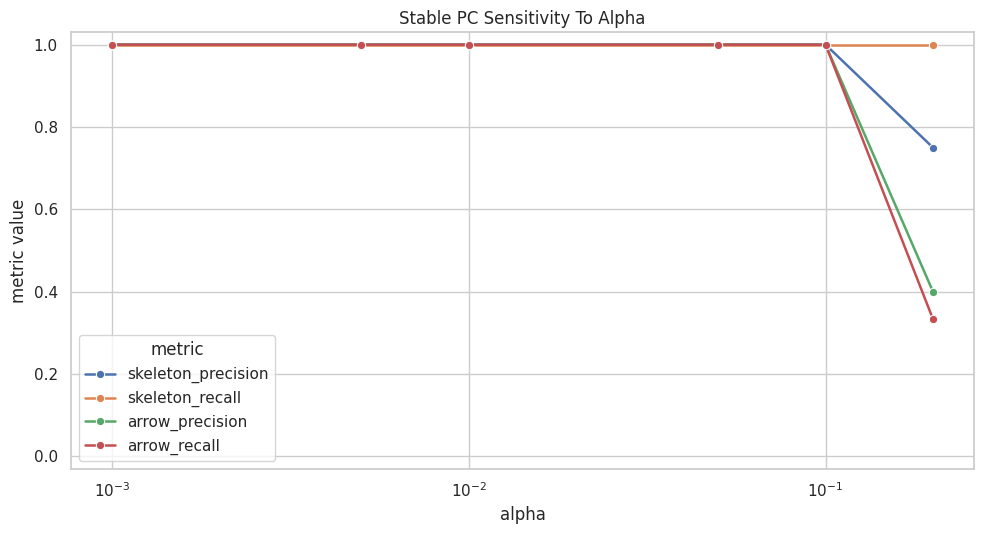

In [15]:
# Build and label the diagnostic visualization for the Plot Alpha Sensitivity section.
alpha_plot = alpha_sensitivity.melt(
    id_vars="alpha",
    value_vars=["skeleton_precision", "skeleton_recall", "arrow_precision", "arrow_recall"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=alpha_plot,
    x="alpha",
    y="value",
    hue="metric",
    marker="o",
    linewidth=1.8,
    ax=ax,
)
ax.set_title("Stable PC Sensitivity To Alpha")
ax.set_xlabel("alpha")
ax.set_ylabel("metric value")
ax.set_ylim(-0.03, 1.03)
ax.set_xscale("log")
plt.tight_layout()
alpha_plot_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_alpha_sensitivity_metrics.png"
fig.savefig(alpha_plot_path, dpi=160, bbox_inches="tight")
plt.show()


The plot stays flat until alpha becomes very permissive. That is a good sign for this synthetic dataset, but the high-alpha deterioration is a useful warning: tuning choices can change causal claims.




#### Draw the High-Alpha Graph

The alpha sensitivity table showed that `alpha=0.20` produces a less reliable graph. Drawing that graph makes the error mode easier to see.


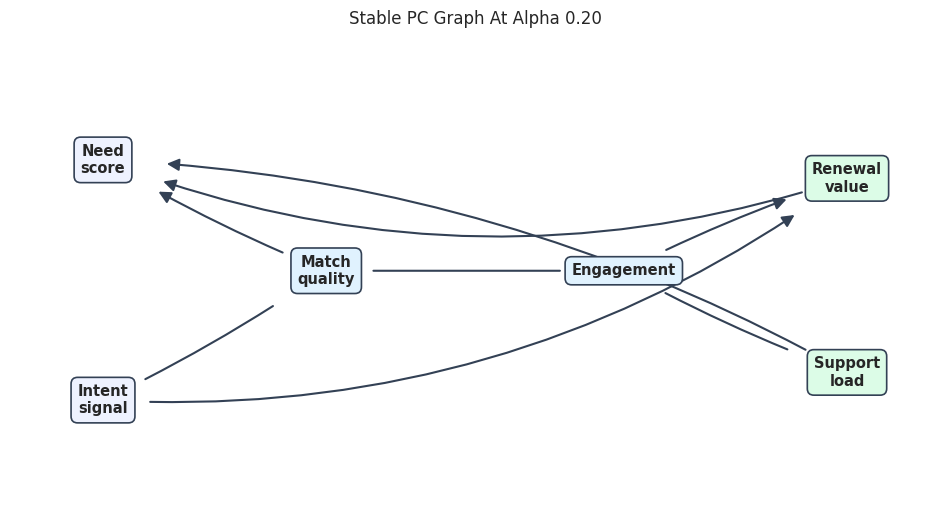

,source,target,mark,edge_kind,causal_learn_edge,endpoint_at_node1,endpoint_at_node2
0,engagement,renewal,-->,directed,engagement --> renewal,TAIL,ARROW
1,engagement,support,---,undirected,engagement --- support,TAIL,TAIL
2,intent,match,---,undirected,intent --- match,TAIL,TAIL
3,intent,renewal,-->,directed,intent --> renewal,TAIL,ARROW
4,match,engagement,---,undirected,match --- engagement,TAIL,TAIL
5,match,need,-->,directed,match --> need,TAIL,ARROW
6,renewal,need,-->,directed,renewal --> need,TAIL,ARROW
7,support,need,-->,directed,support --> need,TAIL,ARROW


In [16]:
high_alpha_result, high_alpha_edge_table = run_pc_edge_table(linear_data, alpha=0.20, stable=True)
high_alpha_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_edges.csv", index=False)
high_alpha_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_pc_graph.png"
draw_edge_table_graph(high_alpha_edge_table, "Stable PC Graph At Alpha 0.20", high_alpha_graph_path)
high_alpha_edge_table


The high-alpha graph contains extra or misoriented relationships that the baseline graph avoided. The lesson is practical: alpha is not a cosmetic parameter; it changes the graph search decisions.




#### Sample Size Sensitivity

Finite samples can make conditional independence tests unstable. The next experiment repeatedly samples smaller subsets of the same linear Gaussian data and runs stable PC with `alpha=0.05`.


In [17]:
sample_sizes = [100, 150, 250, 500, 1_000, 2_500]
sample_rows = []
sample_edge_rows = []
for sample_size in sample_sizes:
    result, edge_table = run_pc_edge_table(
        linear_data,
        alpha=BASE_ALPHA,
        stable=True,
        sample_size=sample_size,
        random_state=RANDOM_SEED,
    )
    metrics = evaluate_learned_graph(f"n_{sample_size}", true_edge_table, edge_table)
    metrics["sample_size"] = sample_size
    metrics["edge_list"] = "; ".join(edge_table["causal_learn_edge"].tolist())
    sample_rows.append(metrics)
    for row in edge_table.itertuples(index=False):
        sample_edge_rows.append({"sample_size": sample_size, **row._asdict()})
sample_size_sensitivity = pd.DataFrame(sample_rows)
sample_size_edges = pd.DataFrame(sample_edge_rows)
sample_size_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_metrics.csv", index=False)
sample_size_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_edges.csv", index=False)
sample_size_sensitivity[
    [
        "sample_size",
        "learned_edges",
        "skeleton_precision",
        "skeleton_recall",
        "arrow_precision",
        "arrow_recall",
        "reversed_arrows",
        "unresolved_true_edges",
        "edge_list",
    ]
]


,sample_size,learned_edges,skeleton_precision,skeleton_recall,arrow_precision,arrow_recall,reversed_arrows,unresolved_true_edges,edge_list
0,100,6,1.0,1.000000,0.8,0.666667,1,1,engagement --> support; intent --> match; intent --- renewal; match --> engagement; need --> match; renewal --> engagement
1,150,5,1.0,0.833333,1.0,0.666667,0,1,engagement --> support; intent --> match; intent --- renewal; match --> engagement; need --> match
2,250,6,1.0,1.000000,0.6,0.500000,2,1,intent --> match; intent --- renewal; match --> engagement; need --> match; renewal --> engagement; support --> engagement
3,500,6,1.0,1.000000,1.0,1.000000,0,0,engagement --> renewal; engagement --> support; intent --> match; intent --> renewal; match --> engagement; need --> match
4,1000,6,1.0,1.000000,1.0,1.000000,0,0,engagement --> renewal; engagement --> support; intent --> match; intent --> renewal; match --> engagement; need --> match
5,2500,6,1.0,1.000000,1.0,1.000000,0,0,engagement --> renewal; engagement --> support; intent --> match; intent --> renewal; match --> engagement; need --> match


The smaller samples recover the broad structure less reliably. Some directions become unresolved or reversed, while larger samples return to the intended graph. This is the finite-sample side of the CI-test story from lesson 03.


#### Plot Sample Size Sensitivity

This plot shows graph recovery metrics as the available sample grows. It is often one of the most useful diagnostics for explaining why a discovery graph should be treated cautiously.


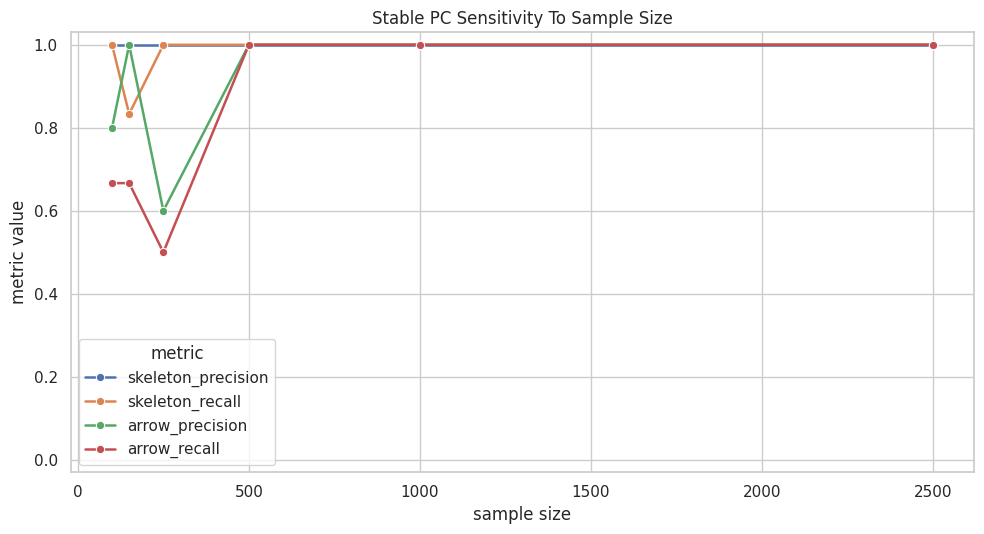

In [18]:
sample_plot = sample_size_sensitivity.melt(
    id_vars="sample_size",
    value_vars=["skeleton_precision", "skeleton_recall", "arrow_precision", "arrow_recall"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=sample_plot,
    x="sample_size",
    y="value",
    hue="metric",
    marker="o",
    linewidth=1.8,
    ax=ax,
)
ax.set_title("Stable PC Sensitivity To Sample Size")
ax.set_xlabel("sample size")
ax.set_ylabel("metric value")
ax.set_ylim(-0.03, 1.03)
plt.tight_layout()
sample_plot_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_metrics.png"
fig.savefig(sample_plot_path, dpi=160, bbox_inches="tight")
plt.show()


The plot improves as sample size increases. Skeleton recovery is generally easier than orientation recovery, which is a common pattern in causal discovery benchmarks.




#### Stable PC versus Original PC

The `stable=True` option makes skeleton discovery less dependent on variable ordering. The code below compares stable and original PC on moderate sample sizes where finite-sample differences can show up.


In [19]:
stable_comparison_rows = []
stable_edge_rows = []
for stable in [True, False]:
    for sample_size in [150, 250, 500]:
        result, edge_table = run_pc_edge_table(
            linear_data,
            alpha=BASE_ALPHA,
            stable=stable,
            sample_size=sample_size,
            random_state=RANDOM_SEED,
        )
        metrics = evaluate_learned_graph(f"stable_{stable}_n_{sample_size}", true_edge_table, edge_table)
        metrics["stable"] = stable
        metrics["sample_size"] = sample_size
        metrics["edge_list"] = "; ".join(edge_table["causal_learn_edge"].tolist())
        stable_comparison_rows.append(metrics)
        for row in edge_table.itertuples(index=False):
            stable_edge_rows.append({"stable": stable, "sample_size": sample_size, **row._asdict()})
stable_comparison = pd.DataFrame(stable_comparison_rows)
stable_edge_table = pd.DataFrame(stable_edge_rows)
stable_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_stable_vs_original_metrics.csv", index=False)
stable_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_stable_vs_original_edges.csv", index=False)
stable_comparison[
    [
        "stable",
        "sample_size",
        "learned_edges",
        "skeleton_precision",
        "skeleton_recall",
        "arrow_precision",
        "arrow_recall",
        "edge_list",
    ]
]


,stable,sample_size,learned_edges,skeleton_precision,skeleton_recall,arrow_precision,arrow_recall,edge_list
0,True,150,5,1.0,0.833333,1.0,0.666667,engagement --> support; intent --> match; intent --- renewal; match --> engagement; need --> match
1,True,250,6,1.0,1.000000,0.6,0.500000,intent --> match; intent --- renewal; match --> engagement; need --> match; renewal --> engagement; support --> engagement
2,True,500,6,1.0,1.000000,1.0,1.000000,engagement --> renewal; engagement --> support; intent --> match; intent --> renewal; match --> engagement; need --> match
3,False,150,5,1.0,0.833333,1.0,0.666667,engagement --> support; intent --> match; intent --- renewal; match --> engagement; need --> match
4,False,250,6,1.0,1.000000,0.6,0.500000,intent --> match; intent --- renewal; match --> engagement; need --> match; renewal --> engagement; support --> engagement
5,False,500,6,1.0,1.000000,0.6,0.500000,intent --> match; intent --- renewal; match --> engagement; need --> match; renewal --> engagement; support --> engagement


The stable and original variants can agree at some sample sizes and differ at others. Stable PC is often preferred for reproducible skeleton discovery because it reduces order-dependence during edge removal.




#### Stress Test: Fisher-Z PC on Nonlinear Continuous Data

The nonlinear dataset has the same broad variables but violates the linear Gaussian assumptions more strongly. Running Fisher-Z PC here is useful as a cautionary example: the algorithm still returns a graph, but the test may not match the data-generating mechanisms.


In [20]:
nonlinear_pc_result, nonlinear_pc_edge_table = run_pc_edge_table(nonlinear_data, alpha=BASE_ALPHA, stable=True)
nonlinear_metrics = pd.DataFrame([evaluate_learned_graph("nonlinear_fisherz_pc", true_edge_table, nonlinear_pc_edge_table)])
nonlinear_pc_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_fisherz_pc_edges.csv", index=False)
nonlinear_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_fisherz_pc_metrics.csv", index=False)
nonlinear_pc_edge_table


,source,target,mark,edge_kind,causal_learn_edge,endpoint_at_node1,endpoint_at_node2
0,engagement,match,-->,directed,engagement --> match,TAIL,ARROW
1,engagement,renewal,-->,directed,engagement --> renewal,TAIL,ARROW
2,engagement,support,---,undirected,engagement --- support,TAIL,TAIL
3,intent,match,-->,directed,intent --> match,TAIL,ARROW
4,intent,renewal,-->,directed,intent --> renewal,TAIL,ARROW
5,match,renewal,-->,directed,match --> renewal,TAIL,ARROW
6,need,engagement,---,undirected,need --- engagement,TAIL,TAIL
7,need,match,-->,directed,need --> match,TAIL,ARROW


The nonlinear Fisher-Z graph is less faithful to the true base graph. This does not mean PC is useless; it means the test choice and data-generating assumptions are no longer aligned.


#### Draw the Nonlinear Stress-Test Graph

The figure shows the stress-test graph in the same layout as the baseline. This makes extra and reversed edges easier to spot.


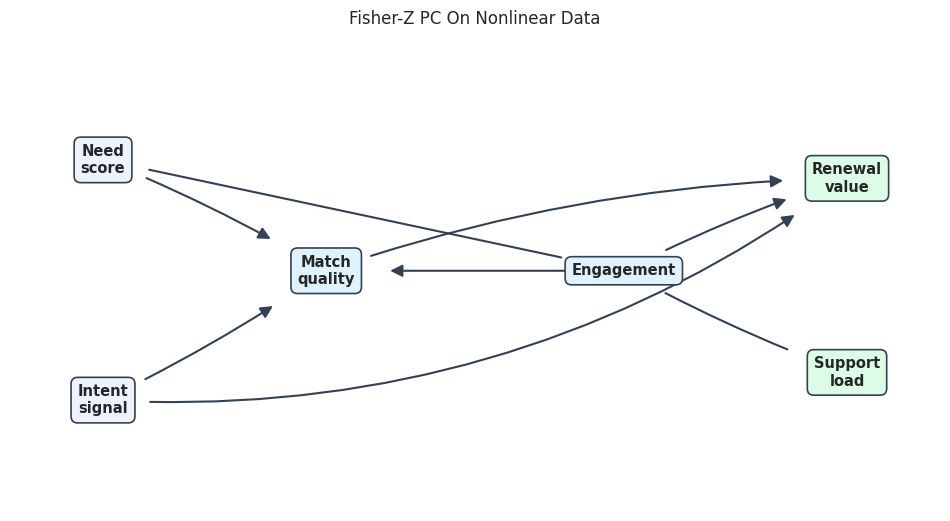

,candidate,learned_edges,skeleton_tp,skeleton_fp,skeleton_fn,skeleton_precision,skeleton_recall,arrow_tp,arrow_fp,arrow_fn,arrow_precision,arrow_recall,reversed_arrows,unresolved_true_edges
0,nonlinear_fisherz_pc,8,6,2,0,0.75,1.0,4,2,2,0.666667,0.666667,1,1


In [21]:
nonlinear_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_fisherz_pc_graph.png"
draw_edge_table_graph(nonlinear_pc_edge_table, "Fisher-Z PC On Nonlinear Data", nonlinear_graph_path)
nonlinear_metrics


The metrics and graph both point in the same direction: when the CI test is mismatched, PC can preserve the wrong adjacencies or orient arrows poorly. Later nonlinear-method lessons will revisit this issue with methods designed for richer functional relationships.


#### Compare Baseline and Stress-Test Metrics

This compact table puts the friendly baseline, high-alpha run, small-sample run, and nonlinear stress test side by side.


In [22]:
comparison_rows = []
comparison_rows.append(evaluate_learned_graph("baseline_linear_alpha_0_05", true_edge_table, baseline_edge_table))
comparison_rows.append(evaluate_learned_graph("high_alpha_0_20", true_edge_table, high_alpha_edge_table))
small_sample_edges = sample_size_edges[sample_size_edges["sample_size"].eq(150)][
    ["source", "target", "mark", "edge_kind", "causal_learn_edge", "endpoint_at_node1", "endpoint_at_node2"]
]
comparison_rows.append(evaluate_learned_graph("small_sample_n_150", true_edge_table, small_sample_edges))
comparison_rows.append(evaluate_learned_graph("nonlinear_fisherz", true_edge_table, nonlinear_pc_edge_table))
scenario_comparison = pd.DataFrame(comparison_rows)
scenario_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_scenario_comparison_metrics.csv", index=False)
scenario_comparison[
    [
        "candidate",
        "learned_edges",
        "skeleton_precision",
        "skeleton_recall",
        "arrow_precision",
        "arrow_recall",
        "reversed_arrows",
        "unresolved_true_edges",
    ]
]


,candidate,learned_edges,skeleton_precision,skeleton_recall,arrow_precision,arrow_recall,reversed_arrows,unresolved_true_edges
0,baseline_linear_alpha_0_05,6,1.00,1.000000,1.000000,1.000000,0,0
1,high_alpha_0_20,8,0.75,1.000000,0.400000,0.333333,1,3
2,small_sample_n_150,5,1.00,0.833333,1.000000,0.666667,0,1
3,nonlinear_fisherz,8,0.75,1.000000,0.666667,0.666667,1,1


The comparison shows three distinct failure modes: too-permissive alpha can add edges, small samples can weaken orientation recovery, and nonlinear mechanisms can break Fisher-Z assumptions. These are exactly the diagnostics a PC analysis should include.





## Reporting and Takeaways

### Report-Ready PC Checklist

The final checklist turns this lesson into reporting guidance. A useful PC report should include the graph, the CI test, the alpha threshold, stability diagnostics, and assumption caveats.


| report_item | example_from_this_lesson | why_it_matters |
| --- | --- | --- |
| Data regime | Continuous linear Gaussian synthetic data | Fisher-Z is only appropriate when the data are close to its assumptions. |
| CI test and alpha | Fisher-Z with alpha = 0.05 | Edge removal depends directly on conditional independence decisions. |
| Stable setting | stable=True for the baseline graph | Stable PC reduces order-dependence in skeleton search. |
| Graph type | Learned directed/undirected graph from PC | Unoriented edges should not be silently converted into causal arrows. |
| Sensitivity checks | Alpha, sample size, stable versus original PC, nonlinear stress test | A single graph can hide tuning and assumption fragility. |
| Edge-level audit | Saved learned edge tables and separating sets | Stakeholders need to know which causal claims changed along with the summary score. |


The checklist is the habit to carry forward. PC is more than an API call; it is a sequence of assumptions, tests, graph edits, and sensitivity checks that need to be made visible.


## Summary


The continuous PC workflow is now complete. The next step extends the same workflow to prior knowledge, missing values, and discrete data, where the choice of CI test and background constraints becomes even more visible.
